# FYP Continual Learning Experiment

This notebook imports reusable logic from the Python scripts and runs the experiment interactively.

In [1]:
%load_ext autoreload
%autoreload 2


In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "initial_pipeline").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from initial_pipeline.core_pipeline import CONFIG, configure_vast_ai, prepare_data, print_task_summary
from initial_pipeline.experiment_runner import run_experiment, build_cl_summary, print_and_save_comparison_tables, generate_all_plots


## Vast.ai / GPU setup

On Vast.ai, upload the project folder to a location such as `/workspace/fyp`. Put the CSV files in `/workspace/fyp/data/processed`, then set `data_dir` below. For local runs, leave both values as `None`.

In [3]:
DATA_DIR = "/workspace/fyp_continuallearning_selfdistillation/data/processed"
OUTPUT_DIR = "/workspace/fyp_continuallearning_selfdistillation/outputs"

configure_vast_ai(DATA_DIR, OUTPUT_DIR, require_gpu=True)


Runtime diagnostics

Python         : 3.12.13

PyTorch        : 2.3.1+cu121

CUDA available : True

GPU            : NVIDIA GeForce RTX 4090

...

CPU cores      : 144

Vast.ai        : NO

Active device  : CUDA

Precision      : 32

{'paths': {'demand_csv': '/workspace/fyp_continuallearning_selfdistillation/data/processed/demand_forecasting.csv',
  'rl_csv': '/workspace/fyp_continuallearning_selfdistillation/data/processed/rl_environment.csv',
  'checkpoints': '/workspace/fyp_continuallearning_selfdistillation/outputs/checkpoints',
  'results': '/workspace/fyp_continuallearning_selfdistillation/outputs/results',
  'logs': '/workspace/fyp_continuallearning_selfdistillation/outputs/logs',
  'plots': '/workspace/fyp_continuallearning_selfdistillation/outputs/plots'},
 'tasks': [{'task_id': 1,
   'name': 'Baseline_2023_H1',
   'start': '2023-01-01',
   'end': '2023-05-31',
   'regime': 'baseline'},
  {'task_id': 2,
   'name': 'MegaSale_2023',
   'start': '2023-06-01',
   'end': '2023-12-31',
   'regime': 'mega_sale'},
  {'task_id': 3,
   'name': 'Baseline_2024_H1',
   'start': '2024-01-01',
   'end': '2024-05-31',
   'regime': 'baseline'},
  {'task_id': 4,
   'name': 'MegaSale_2024',
   'start': '2024-06-01',
   'end'

In [4]:
tft_tasks, rl_tasks, tft_df, rl_df = prepare_data()
print_task_summary(tft_tasks, rl_tasks)


Loading datasets...

Demand CSV  : 9,864 rows × 66 cols

RL CSV      : 9,864 rows × 86 cols

✓ Data loaded and cleaned

┏━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┓
┃ Task ┃ Name             ┃ Period                   ┃ TFT rows ┃ RL rows ┃
┡━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━┩
│ 1    │ Baseline_2023_H1 │ 2023-01-01 -> 2023-05-31 │ 1,359    │ 1,359   │
│ 2    │ MegaSale_2023    │ 2023-06-01 -> 2023-12-31 │ 1,926    │ 1,926   │
│ 3    │ Baseline_2024_H1 │ 2024-01-01 -> 2024-05-31 │ 1,368    │ 1,368   │
│ 4    │ MegaSale_2024    │ 2024-06-01 -> 2024-12-31 │ 1,926    │ 1,926   │
│ 5    │ Baseline_2025_H1 │ 2025-01-01 -> 2025-05-31 │ 1,359    │ 1,359   │
│ 6    │ MegaSale_2025    │ 2025-06-01 -> 2025-12-31 │ 1,926    │ 1,926   │
└──────┴──────────────────┴──────────────────────────┴──────────┴─────────┘

In [ ]:
from initial_pipeline.core_pipeline import CONFIG

CONFIG["hardware"]["compile"] = False
print(CONFIG["hardware"]["compile"])

In [6]:
run_experiment(tft_tasks, rl_tasks)


==============================================================

  CONTINUAL LEARNING EXPERIMENT START

==============================================================

═══ MODEL TYPE: FORECASTING ═══

  ── CL Method: naive ──

...

Eval task 4: avg_episode_reward=7795.3385  cumulative_profit=511820034.3622  pricing_regret=24.1474

Eval task 5: avg_episode_reward=6048.4772  cumulative_profit=573652605.3712  pricing_regret=38.3506

Eval task 6: avg_episode_reward=7859.2833  cumulative_profit=559835977.9738  pricing_regret=26.6821

Results saved → /workspace/fyp_continuallearning_selfdistillation/outputs/results/all_metrics.csv

═══ EXPERIMENT COMPLETE (104.3 min) ═══

In [7]:
cl_summary = build_cl_summary()
tables = print_and_save_comparison_tables(cl_summary)


CL Summary (BWT / FWT):

model_type cl_method    primary_metric  avg_final_perf  avg_online_perf           bwt  fwt
forecasting     naive              mase    2.889800e+00     2.183100e+00 -8.481000e-01  0.0
forecasting       ewc              mase    9.147000e-01     9.248000e-01  1.210000e-02  0.0
forecasting    replay              mase    2.152400e+00     3.286600e+00  1.361100e+00  0.0
forecasting      sdft              mase    2.683900e+00     3.012500e+00  3.942000e-01  0.0
         rl     naive cumulative_profit    4.831934e+08     5.062160e+08 -2.762710e+07  0.0
         rl       ewc cumulative_profit    5.199544e+08     5.232093e+08 -3.905927e+06  0.0
         rl    recall cumulative_profit    4.805034e+08     5.002325e+08 -2.367490e+07  0.0
         rl      sdft cumulative_profit    5.224498e+08     5.040922e+08  2.202909e+07  0.0


  FORECASTING - MASE (lower is better)
           Task 1  Task 2  Task 3  Task 4  Task 5  Task 6
cl_method                                                
ewc        0.6798  0.8626  0.8251  0.8792  1.0123  1.0188
naive      0.8601  1.6857  1.3802  2.3589  2.0122  5.0797
replay     0.6022  1.2292  4.7642  2.9317  4.1613  2.1637
sdft       1.0413  4.6051  1.8502  4.0003  2.3830  3.4143

  FORECASTING - sMAPE
            Task 1    Task 2    Task 3    Task 4    Task 5    Task 6
cl_method                                                           
ewc        64.2431   82.6213   69.7655   81.5332   74.0223   84.6794
naive      55.9282   88.9717   65.1829   99.9825   80.0312  143.8219
replay     49.1321   74.0929  130.0196  112.4571  132.2815  102.0997
sdft       67.6078  128.7175   85.6327  121.3138   92.5135  113.6932

  RL - CUMULATIVE PROFIT (higher is better)
                 Task 1        Task 2        Task 3        Task 4        Task 5        Task 6
cl_method                           

Generating plots...

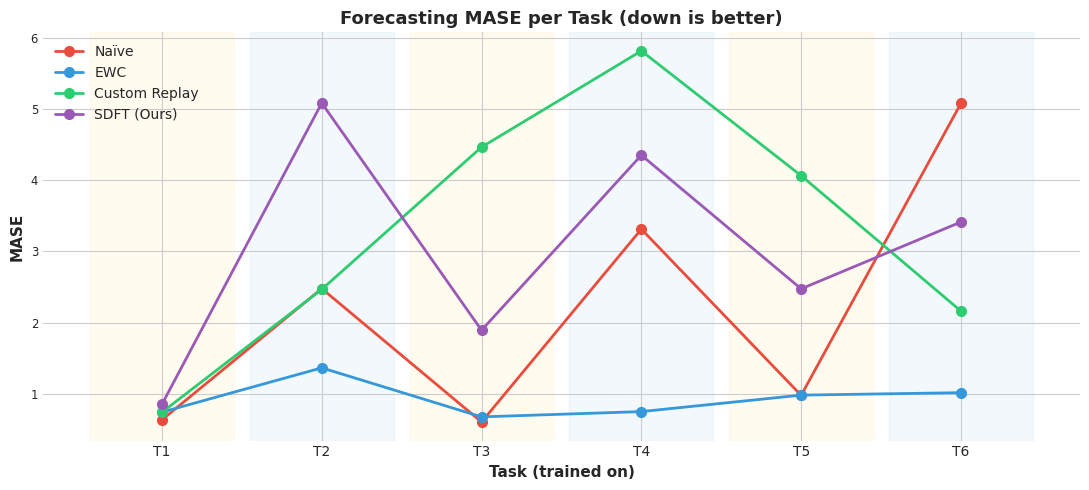

Saved: /workspace/fyp_continuallearning_selfdistillation/outputs/plots/mase_online_forecasting.png

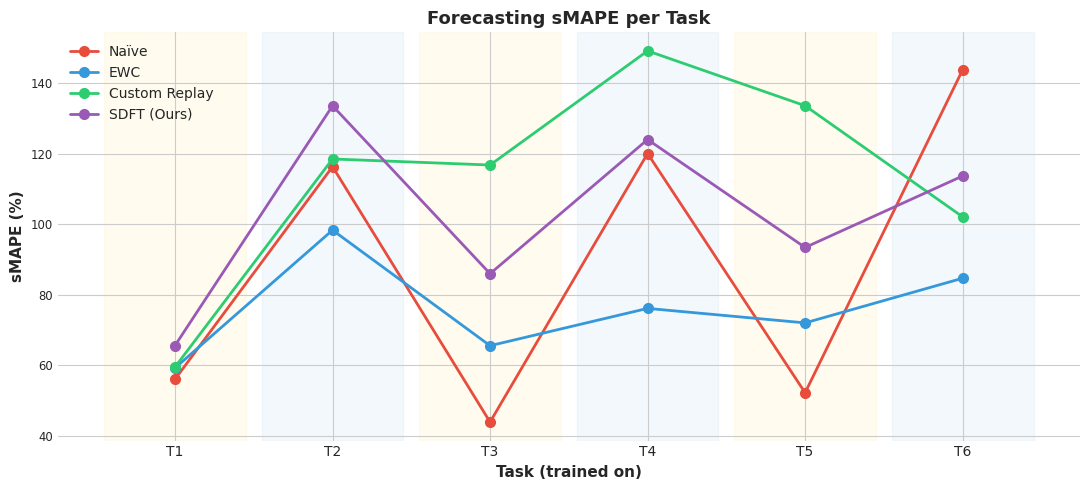

Saved: /workspace/fyp_continuallearning_selfdistillation/outputs/plots/smape_online_forecasting.png

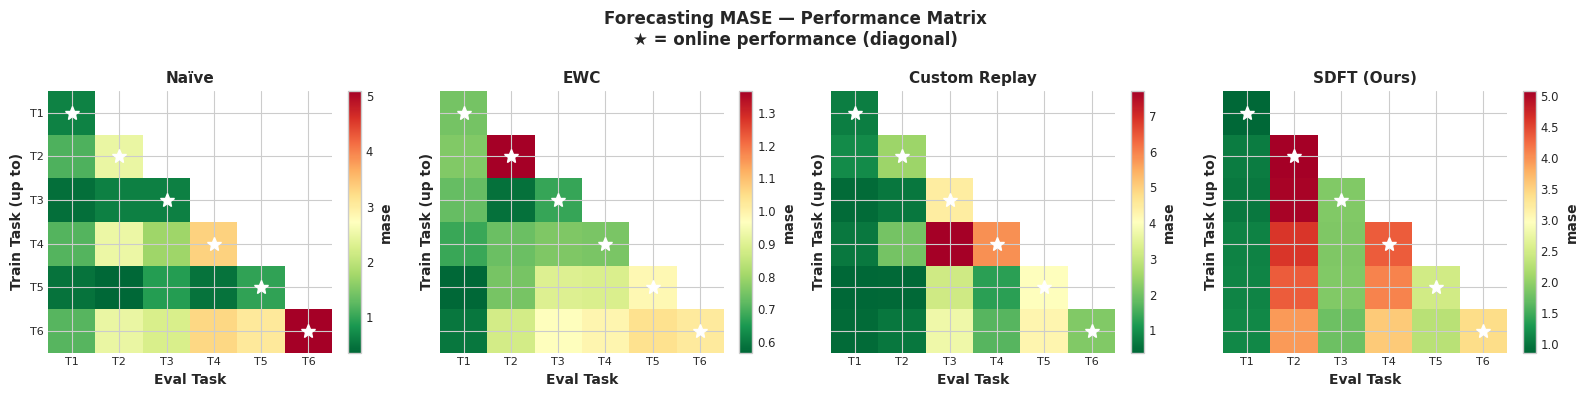

Saved: /workspace/fyp_continuallearning_selfdistillation/outputs/plots/perfmat_mase_forecasting.png

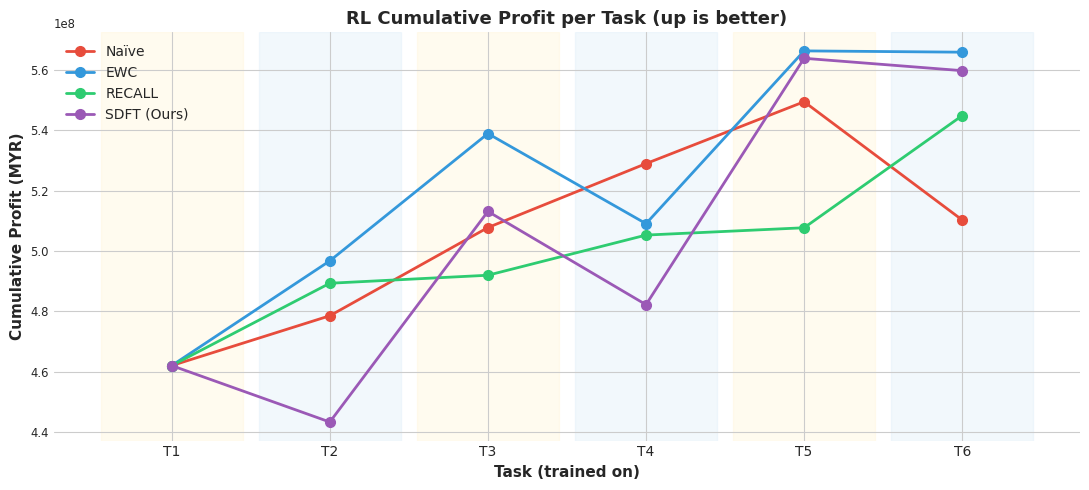

Saved: /workspace/fyp_continuallearning_selfdistillation/outputs/plots/profit_online_rl.png

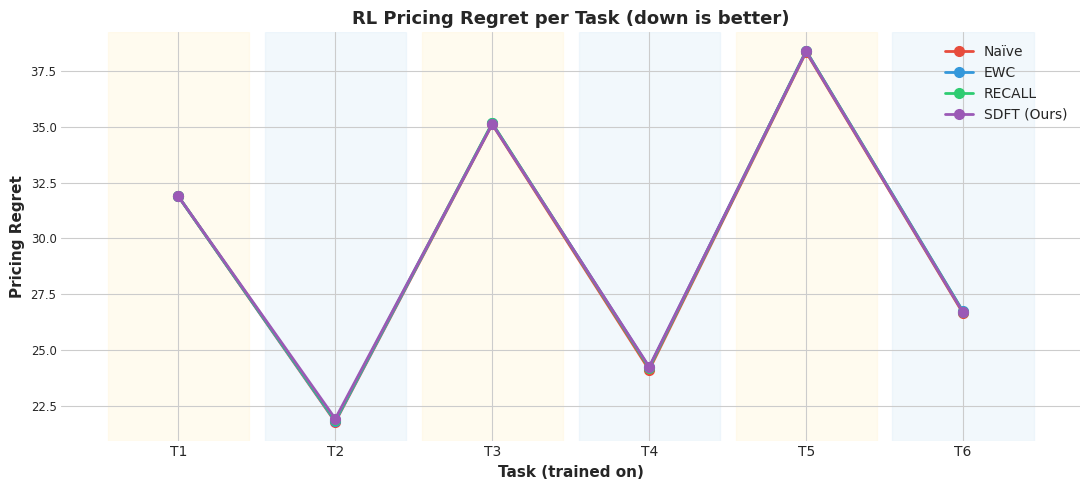

Saved: /workspace/fyp_continuallearning_selfdistillation/outputs/plots/regret_online_rl.png

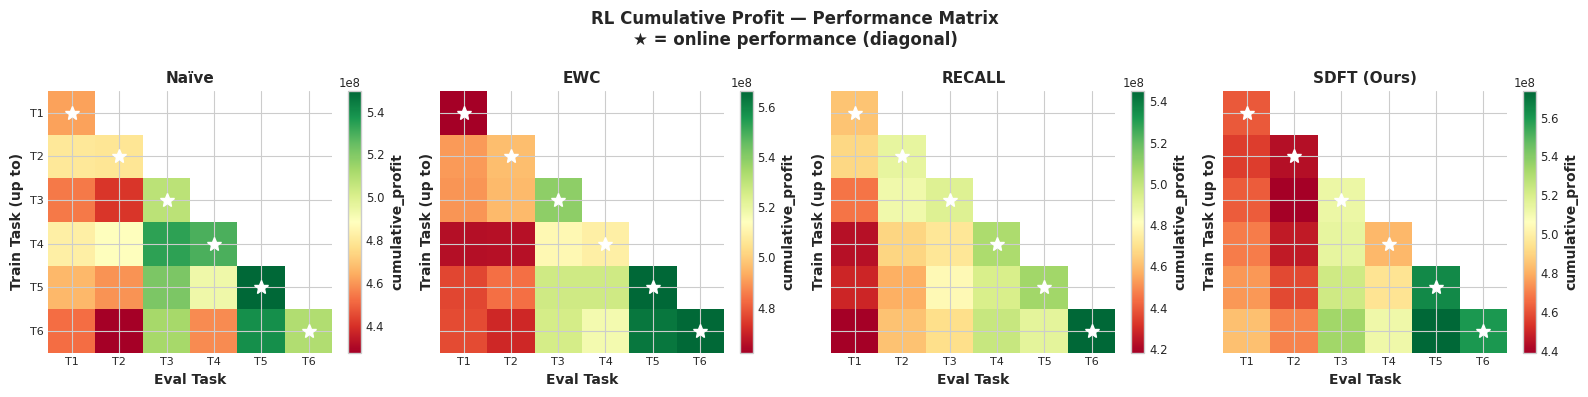

Saved: /workspace/fyp_continuallearning_selfdistillation/outputs/plots/perfmat_cumulative_profit_rl.png

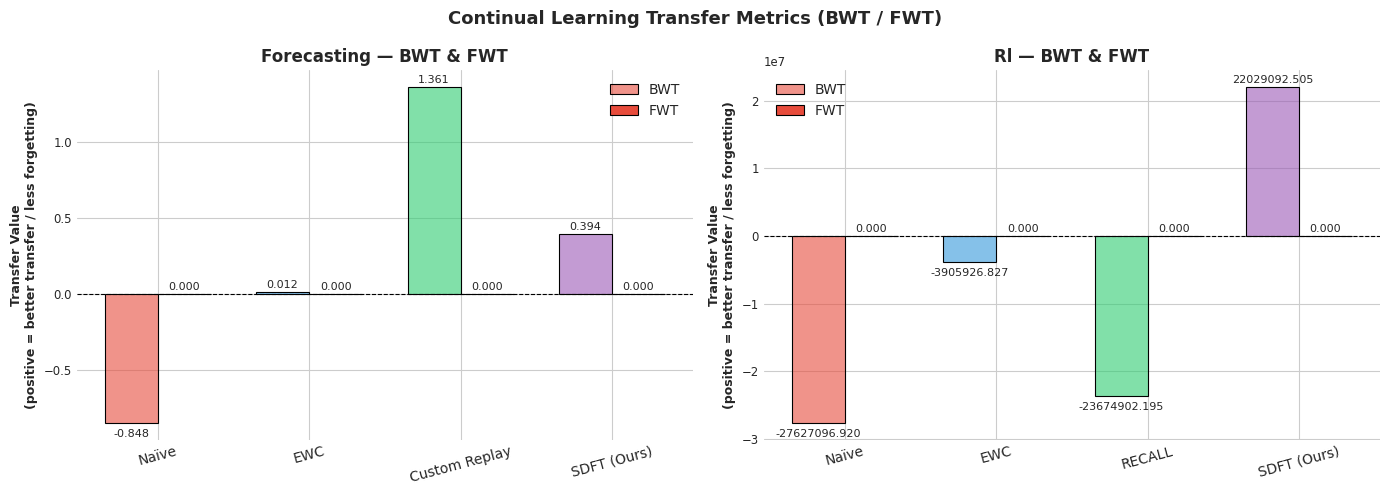

Saved: /workspace/fyp_continuallearning_selfdistillation/outputs/plots/bwt_fwt_comparison.png

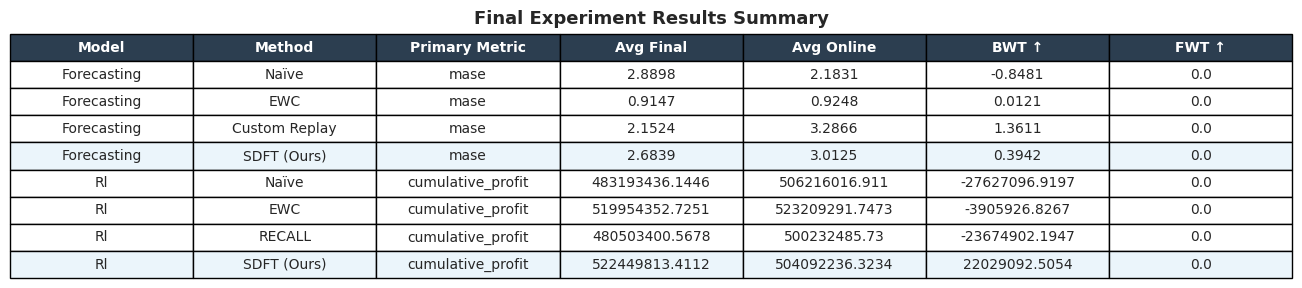

Saved: /workspace/fyp_continuallearning_selfdistillation/outputs/plots/final_summary_table.png

All plots saved to plots/

,model_type,cl_method,primary_metric,avg_final_perf,avg_online_perf,bwt,fwt
0,forecasting,naive,mase,2.889800e+00,2.183100e+00,-8.481000e-01,0.0
1,forecasting,ewc,mase,9.147000e-01,9.248000e-01,1.210000e-02,0.0
2,forecasting,replay,mase,2.152400e+00,3.286600e+00,1.361100e+00,0.0
3,forecasting,sdft,mase,2.683900e+00,3.012500e+00,3.942000e-01,0.0
4,rl,naive,cumulative_profit,4.831934e+08,5.062160e+08,-2.762710e+07,0.0
5,rl,ewc,cumulative_profit,5.199544e+08,5.232093e+08,-3.905927e+06,0.0
6,rl,recall,cumulative_profit,4.805034e+08,5.002325e+08,-2.367490e+07,0.0
7,rl,sdft,cumulative_profit,5.224498e+08,5.040922e+08,2.202909e+07,0.0


In [9]:
generate_all_plots(cl_summary)
